# ENVIRONMENTS
Create conda environments

In [ ]:
#!conda env create -f reinvent4.yaml
#!conda env create -f nonconformist.yaml
#!conda env create -f chemprop.yaml

# Datasets
This notebook loads DRD2 and EGFR datasets, cleans molecules/labels, creates train/val/test splits, and exports smaller subsets for downstream experiments.

Run in conda env: reinvent4

In [ ]:
#unzip datasets - needed to build the models

!gunzip ./egfr/egfr.csv.gz 
!gunzip ./drd2/drd2.csv.gz 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load raw tables.
drd2 = pd.read_csv("./drd2/drd2.csv", sep=';') #datasets downloaded from chembl
egfr = pd.read_csv("./egfr/egfr.csv", sep=';') #datasets downloaded from chembl

# Dataset Cleaning
Remove incomplete entries, standardize SMILES, remove salts, and aggregate repeated measurements.

In [ ]:
# Keep only rows with mandatory columns available.
drd2 = drd2.dropna(subset=["Smiles", "Molecule ChEMBL ID", "pChEMBL Value"])
egfr = egfr.dropna(subset=["Smiles", "Molecule ChEMBL ID", "pChEMBL Value"])

In [ ]:
from rdkit import Chem
from rdkit.Chem import SaltRemover

# Basic validity filter to drop malformed SMILES strings.
def is_valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None

drd2 = drd2[drd2["Smiles"].apply(is_valid_smiles)]

# Canonicalize SMILES so equivalent molecules share one representation.
def canon_smiles(s):
    mol = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(mol, canonical=True)


# Remove common salts/counterions while preserving the main scaffold.
def strip_salts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = remover.StripMol(mol, dontRemoveEverything=True)
    return Chem.MolToSmiles(mol, canonical=True)


remover = SaltRemover.SaltRemover()

drd2["canonical_smiles"] = drd2["Smiles"].apply(canon_smiles)
drd2["canonical_smiles"] = drd2["canonical_smiles"].apply(strip_salts)


# Aggregate duplicate measurements first by compound ID, then by canonical structure.
drd2 = (
    drd2
    .groupby("Molecule ChEMBL ID", as_index=False)
    .agg({
        "canonical_smiles": "first",
        "pChEMBL Value": "median"
    })
)

drd2 = (
    drd2
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "Molecule ChEMBL ID": "first",
        "pChEMBL Value": "median"
    })
)

In [ ]:
from rdkit import Chem
from rdkit.Chem import SaltRemover

# Basic validity filter to drop malformed SMILES strings.
def is_valid_smiles(s):
    return Chem.MolFromSmiles(s) is not None

egfr = egfr[egfr["Smiles"].apply(is_valid_smiles)]

# Canonicalize SMILES so equivalent molecules share one representation.
def canon_smiles(s):
    mol = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(mol, canonical=True)


# Remove common salts/counterions while preserving the main scaffold.
def strip_salts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = remover.StripMol(mol, dontRemoveEverything=True)
    return Chem.MolToSmiles(mol, canonical=True)


remover = SaltRemover.SaltRemover()

egfr["canonical_smiles"] = egfr["Smiles"].apply(canon_smiles)
egfr["canonical_smiles"] = egfr["canonical_smiles"].apply(strip_salts)


# Aggregate duplicate measurements first by compound ID, then by canonical structure.
egfr = (
    egfr
    .groupby("Molecule ChEMBL ID", as_index=False)
    .agg({
        "canonical_smiles": "first",
        "pChEMBL Value": "median"
    })
)

egfr = (
    egfr
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "Molecule ChEMBL ID": "first",
        "pChEMBL Value": "median"
    })
)

(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  6., 11., 14., 18., 28.,
        28., 31., 37., 31., 38., 32., 36., 40., 46., 49., 47., 60., 51.,
        53., 68., 53., 71., 74., 76., 66., 72., 76., 70., 59., 58., 69.,
        54., 75., 79., 98., 81., 91., 70., 79., 88., 73., 55., 60., 40.,
        42., 46., 35., 43., 29., 25., 23., 27., 15., 15., 13., 10., 12.,
         5.,  2.,  7.,  2.,  2.,  6.,  0.,  5.,  0.,  0.,  3.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([ 2.05  ,  2.1395,  2.229 ,  2.3185,  2.408 ,  2.4975,  2.587 ,
         2.6765,  2.766 ,  2.8555,  2.945 ,  3.0345,  3.124 ,  3.2135,
         3.303 ,  3.3925,  3.482 ,  3.5715,  3.661 ,  3.7505,  3.84  ,
         3.9295,  4.019 ,  4.1085,  4.198 ,  4.2875,  4.377 ,  4.4665,
         4.556 ,  4.6455,  4.735 ,  4.8245,  4.914 ,  5.0035,  5.093 ,
         5.1825,  5.272 ,  5.3615,  5.451 ,  5.5405,  5.63  ,  5.7195,
        

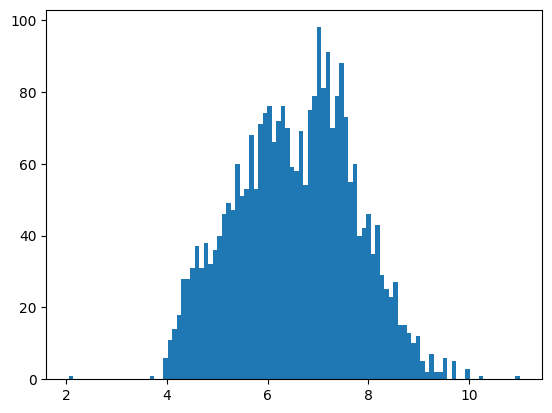

In [ ]:
# Quick sanity check: distribution of DRD2 activity values.
plt.hist(drd2["pChEMBL Value"], bins=100)

(array([3.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 8.700e+01, 1.740e+02, 1.750e+02,
        1.870e+02, 2.340e+02, 2.410e+02, 3.160e+02, 3.270e+02, 3.060e+02,
        3.890e+02, 3.080e+02, 5.640e+02, 5.250e+02, 5.760e+02, 7.600e+02,
        6.780e+02, 6.750e+02, 6.950e+02, 7.010e+02, 6.790e+02, 7.320e+02,
        6.700e+02, 7.110e+02, 9.670e+02, 9.350e+02, 9.820e+02, 1.244e+03,
        9.210e+02, 1.090e+03, 9.700e+02, 1.039e+03, 9.280e+02, 1.120e+03,
        1.280e+03, 1.129e+03, 1.108e+03, 1.118e+03, 1.422e+03, 1.035e+03,
        1.160e+03, 1.218e+03, 1.202e+03, 1.298e+03, 1.082e+03, 9.320e+02,
        1.065e+03, 1.012e+03, 9.990e+02, 8.390e+02, 7.750e+02, 5.370e+02,
        7.770e+02, 4.470e+02, 7.880e+02, 4.840e+02, 3.000e+02, 4.660e+02,
        3.120e+02, 2.110e+02, 2.190e+0

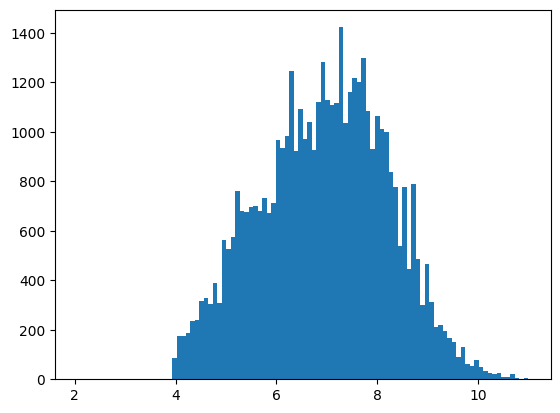

In [ ]:
# Quick sanity check: distribution of EGFR activity values.
plt.hist(egfr["pChEMBL Value"], bins=100)

# Dataset Splits
Create reproducible train/validation/test splits with an 80/10/10 ratio.

In [ ]:
import numpy as np

# Fixed seed for reproducible splits.
np.random.seed(42)

# Shuffle indices before assigning split labels.
indices = np.random.permutation(drd2.index)

# 80% train, 10% validation, 10% test.
n = len(drd2)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

# Save split membership in a dedicated column.
drd2["split"] = ""
drd2.loc[train_idx, "split"] = "train"
drd2.loc[val_idx, "split"] = "val"
drd2.loc[test_idx, "split"] = "test"


In [ ]:
import numpy as np

# Fixed seed for reproducible splits.
np.random.seed(42)

# Shuffle indices before assigning split labels.
indices = np.random.permutation(egfr.index)

# 80% train, 10% validation, 10% test.
n = len(egfr)
train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

# Save split membership in a dedicated column.
egfr["split"] = ""
egfr.loc[train_idx, "split"] = "train"
egfr.loc[val_idx, "split"] = "val"
egfr.loc[test_idx, "split"] = "test"

In [ ]:
# Persist cleaned and split datasets.
drd2.to_csv("./drd2/cleaned_drd2.csv", index=False)
egfr.to_csv("./egfr/cleaned_egfr.csv", index=False)

# Create Smaller EGFR Dataset
Build a reduced EGFR dataset while preserving validation and test sets.

In [ ]:
# Create a smaller version of egfr with 8K training samples
egfr_small = egfr.copy()

train_indices = egfr_small[egfr_small["split"] == "train"].index
small_train_idx = np.random.choice(train_indices, size=8000, replace=False)

keep_idx = np.concatenate([small_train_idx, 
                           egfr_small[egfr_small["split"] == "val"].index.values,
                           egfr_small[egfr_small["split"] == "test"].index.values])

egfr_small = egfr_small.loc[keep_idx]
#egfr_small.to_csv("./egfr/cleaned_egfr_small.csv", index=False)

# Create Super-Small EGFR Dataset
Generate an even smaller training subset for low-data experiments.

In [ ]:
import pandas as pd
import numpy as np

# Reload cleaned EGFR and downsample train split to 800 examples.
egfr_small = pd.read_csv("./egfr/cleaned_egfr.csv")

train_indices = egfr_small[egfr_small["split"] == "train"].index
small_train_idx = np.random.choice(train_indices, size=800, replace=False)

# Keep sampled train rows plus full validation and test rows.
keep_idx = np.concatenate([
    small_train_idx,
    egfr_small[egfr_small["split"] == "val"].index.values,
    egfr_small[egfr_small["split"] == "test"].index.values,
])

egfr_small = egfr_small.loc[keep_idx]
egfr_small.to_csv("./egfr/cleaned_egfr_supersmall.csv", index=False)

# Generate Really-Small EGFR Dataset
Start from the small dataset and further downsample train rows.

In [ ]:
import pandas as pd
import numpy as np

# Reload the small EGFR dataset used as source for further downsampling.
egfr_small = pd.read_csv("./egfr/cleaned_egfr_small.csv")

In [ ]:
# Downsample training rows from the small EGFR dataset.
egfr_reallysmall = egfr_small.copy()

train_indices = egfr_reallysmall[egfr_reallysmall["split"] == "train"].index
small_train_idx = np.random.choice(train_indices, size=2000, replace=False)

# Keep sampled train rows plus full validation and test rows.
keep_idx = np.concatenate([
    small_train_idx,
    egfr_reallysmall[egfr_reallysmall["split"] == "val"].index.values,
    egfr_reallysmall[egfr_reallysmall["split"] == "test"].index.values,
])

egfr_reallysmall = egfr_reallysmall.loc[keep_idx]

In [ ]:
#egfr_reallysmall.to_csv("./egfr/cleaned_egfr_reallysmall.csv", index=False)

# Create SMILES Datasets
Sample train molecules and export full rows and SMILES-only files for model training.

In [ ]:
import numpy as np
import pandas as pd

# Load reduced EGFR dataset and sample train molecules for SMILES export.
egfr_small = pd.read_csv("./egfr/cleaned_egfr_small.csv")

train_indices = egfr_small[egfr_small["split"] == "train"].index
small_train_idx = np.random.choice(train_indices, size=2200, replace=False)

egfr_smiles = egfr_small.loc[small_train_idx]

In [ ]:
# Select active EGFR compounds from the train split using a potency threshold.
activeEGFR = egfr_small[(egfr_small["split"] == "train") & (egfr_small["pChEMBL Value"] >= 7.7)]

In [ ]:
# active compounds selected by potency cutoff.
activeEGFR

,canonical_smiles,Molecule ChEMBL ID,pChEMBL Value,split
3,COCCN1CCN(c2cc(Nc3ncc(C#N)s3)ncn2)CC1,CHEMBL379896,7.855,train
8,Cc1ccc(C2=Nc3c(N)ncnc3NCC2)cc1NC(=O)Nc1cccc(C(...,CHEMBL403706,7.750,train
10,COC(=O)C(Oc1cccc(-c2ccc3sc(C(=N)N)cc3c2)c1)c1c...,CHEMBL596950,8.060,train
13,CS(=O)(=O)CCn1cc(-c2cnc(N)c3c(-c4ccc(NC(=O)Nc5...,CHEMBL2022853,9.000,train
16,C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1OCc1c...,CHEMBL4454948,7.785,train
...,...,...,...,...
7988,Cn1ccc2c([C@H](Nc3cc(C#N)c4ncnc(NCC(C)(C)C)c4c...,CHEMBL5890663,8.435,train
7990,CCC/C=C\C(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccc(F)cc3...,CHEMBL4464589,8.020,train
7993,COc1ccc(OC)c(NC(=O)c2ccc(CSc3ncnc4[nH]cnc34)cc...,CHEMBL1290246,8.230,train
7995,CC(C)(C)CNc1c(C#N)cnc2c(C#N)cc(N[C@H](C3=CN(C4...,CHEMBL5763826,8.300,train


In [ ]:
# Keep the first 2,199 active rows and export for focused active-learning runs.
activeEGFR = activeEGFR[0:2199]
activeEGFR.to_csv("./egfr/cleaned_egfr_active_smiles.csv", index=False)

In [ ]:
# Export sampled EGFR rows (all columns).
egfr_smiles.to_csv("./egfr/cleaned_egfr_small_smiles.csv", index=False)

In [ ]:
# Export SMILES-only text file (no header) for sequence-based generative models.
egfr_smiles["canonical_smiles"].to_csv("./egfr/egfr_smiles_2000.csv", index=False, header=False)

In [ ]:
import numpy as np
import pandas as pd

# Load cleaned DRD2 dataset and sample train molecules for SMILES export.
drd2_small = pd.read_csv("./drd2/cleaned_drd2.csv")

train_indices = drd2_small[drd2_small["split"] == "train"].index
small_train_idx = np.random.choice(train_indices, size=2200, replace=False)

drd2_smiles = drd2_small.loc[small_train_idx]

In [ ]:
# Export sampled DRD2 rows (all columns).
drd2_smiles.to_csv("./drd2/cleaned_drd2_small_smiles.csv", index=False)

In [ ]:
# Export DRD2 SMILES-only text file (no header) for downstream model input.
drd2_smiles["canonical_smiles"].to_csv("./drd2/drd2_smiles_2000.csv", index=False, header=False)

# Dataset Analysis
Quick descriptive statistics to compare activity distributions across subsets.

In [ ]:
import pandas as pd

# Reload exported datasets for quick exploratory checks.
drd2_smiles = pd.read_csv("./drd2/cleaned_drd2_small_smiles.csv")
egfr_smiles = pd.read_csv("./egfr/cleaned_egfr_small_smiles.csv")
egfr_small = pd.read_csv("./egfr/cleaned_egfr_supersmall.csv")
egfr_full = pd.read_csv("./egfr/cleaned_egfr.csv")

In [2]:
# DRD2 train-split activity summary.
drd2_smiles[drd2_smiles["split"] == "train"]["pChEMBL Value"].describe()

count    2200.000000
mean        6.527913
std         1.179743
min         2.050000
25%         5.660000
50%         6.560000
75%         7.390000
max        11.000000
Name: pChEMBL Value, dtype: float64

In [3]:
# EGFR sampled-train activity summary.
egfr_smiles[egfr_smiles["split"] == "train"]["pChEMBL Value"].describe()

count    2200.000000
mean        6.964370
std         1.243358
min         3.180000
25%         6.090000
50%         7.050000
75%         7.890000
max        10.620000
Name: pChEMBL Value, dtype: float64

In [4]:
# EGFR small-dataset train activity summary.
egfr_small[egfr_small["split"] == "train"]["pChEMBL Value"].describe()

count    800.000000
mean       6.975594
std        1.246619
min        4.000000
25%        6.107500
50%        7.022500
75%        7.890000
max       10.570000
Name: pChEMBL Value, dtype: float64

In [5]:
# Full EGFR train activity summary for comparison.
egfr_full[egfr_full["split"] == "train"]["pChEMBL Value"].describe()

count    36220.000000
mean         6.946822
std          1.275015
min          2.050000
25%          6.030000
50%          7.010000
75%          7.870000
max         11.000000
Name: pChEMBL Value, dtype: float64

In [ ]:
# check for MW, TPSA 

from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

def mean_mw_from_smiles(smiles_list):
    mw_values = []
    tpsa_values=[]
    invalid_smiles = []

    for smi in smiles_list:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            invalid_smiles.append(smi)
            continue
        mw_values.append(Descriptors.MolWt(mol))
        tpsa_values.append(Descriptors.TPSA(mol))  

    mean_mw = float(np.mean(mw_values)) if mw_values else np.nan
    mean_tpsa = float(np.mean(tpsa_values)) if tpsa_values else np.nan
    
    return mean_mw, mean_tpsa, mw_values, tpsa_values, invalid_smiles



In [ ]:
# number for the table
mean_mw, mean_tpsa, mw_values, tpsa_values, invalid_smiles=mean_mw_from_smiles(egfr_full[egfr_full["split"] == "train"]["canonical_smiles"].tolist())
mean_mw, mean_tpsa

(481.2830859678056, 109.20507123136389)

In [ ]:
# numbers for the table
mean_mw, mean_tpsa, mw_values, tpsa_values, invalid_smiles=mean_mw_from_smiles(egfr_small[egfr_small["split"] == "train"]["canonical_smiles"].tolist())
mean_mw, mean_tpsa

(479.84321788166767, 108.0404)

In [ ]:
# numbers for the table
mean_mw, mean_tpsa, mw_values, tpsa_values, invalid_smiles=mean_mw_from_smiles(egfr_smiles[egfr_smiles["split"] == "train"]["canonical_smiles"].tolist())
mean_mw, mean_tpsa

(483.723850732122, 110.06358636363636)

In [ ]:
# numbers for the table
mean_mw, mean_tpsa, mw_values, tpsa_values, invalid_smiles=mean_mw_from_smiles(drd2_smiles[drd2_smiles["split"] == "train"]["canonical_smiles"].tolist())
mean_mw, mean_tpsa

(428.8188983206065, 70.49740909090909)

In [ ]:
# Check split counts to validate partition sizes.
egfr_full["split"].value_counts()

split
train    36220
test      4528
val       4527
Name: count, dtype: int64

In [ ]:
# Save DRD2 table after split assignment for downstream experiments.
drd2_small.to_csv("./drd2/cleaned_drd2_small.csv", index=False)

In [ ]:
import pandas as pd
supersmall=pd.read_csv("./egfr/cleaned_egfr_supersmall.csv")
smi_supersmall=supersmall[supersmall["split"]=="train"]["canonical_smiles"]
smi_supersmall.to_csv("./egfr/cleaned_egfr_supersmall_smiles.csv", index=False, header=False)